<a href="https://colab.research.google.com/github/TorresZ314/EE344ML_homework/blob/main/344Assignment_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [50]:
# === Imports ===
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
import matplotlib.pyplot as plt
import statsmodels.api as sm

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)


In [ ]:
# === Load dataset ===
DATA_PATH = "usina_with_outliers.csv"
df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
display(df.head())

target_col = df.columns[-1]  # House_Price
print("Target column:", target_col)


Shape: (9568, 5)


,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


Target column: PE


**Question 1.1**
1. I would like to choose standard Linear Regression because I only have 4 features.
2. And the data describes a Combined Cycle Power Plant. **All four variables (Temperature, Vacuum, Pressure, Humidity) are physically distinct and likely contribute to the Power Output (PE).**
3. For the library, I would choose Statsmodels OLS because it is easier to calculate the Cook's Distance.(just one line command)

In [ ]:
X = df[['AT', 'V', 'AP', 'RH']]
y = df['PE']

# 2. Add constant for OLS

# 2. Add constant for OLS
X_const = sm.add_constant(X)

# 3. Fit OLS on the WHOLE dataset
model = sm.OLS(y, X_const).fit()

# 4. Calculate Cook's Distance
influence = model.get_influence()
(cooks_d, p_values) = influence.cooks_distance

# 5. Define Threshold (4/n)
n = len(df)
threshold = 4 / n
print(f"Threshold: {threshold}")

# 6. Remove Outliers
outlier_mask = cooks_d > threshold
print(f"Outliers detected: {outlier_mask.sum()}")


df_clean = df[~outlier_mask]

# 7. Export EXACTLY as requested
df_clean.to_csv('usina.csv', index=False)
print("Saved usina.csv")

Threshold: 0.0004180602006688963
Outliers detected: 120
Saved usina.csv


**Quesiton 2, Train the model and compare the metrics**

In [39]:
DATA_PATH = "usina_with_outliers.csv"
df = pd.read_csv(DATA_PATH)
X = df.drop(columns=[target_col]).copy()
y = df[target_col].values.reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, shuffle=True
)

print("Train:", X_train.shape, y_train.shape)
print("Test :", X_test.shape, y_test.shape)

CLEAN_DATA_PATH = "usina.csv"
df_clean = pd.read_csv(CLEAN_DATA_PATH)
X_clean = df_clean.drop(columns=[target_col]).copy()
y_clean = df_clean[target_col].values.reshape(-1, 1)
X_train_cl, X_test_cl, y_train_cl, y_test_cl = train_test_split(
    X_clean, y_clean, test_size=0.30, random_state=42, shuffle=True
)

print("Train_cl:", X_train_cl.shape, y_train_cl.shape)
print("Test_cl :", X_test_cl.shape, y_test_cl.shape)



Train: (6697, 4) (6697, 1)
Test : (2871, 4) (2871, 1)
Train_cl: (6613, 4) (6613, 1)
Test_cl : (2835, 4) (2835, 1)


Helper functions

In [40]:

def eval_metrics(y_true, y_pred):
    y_true = y_true.reshape(-1)
    y_pred = y_pred.reshape(-1)
    return {
        "mse": mean_squared_error(y_true, y_pred),
        "mae": mean_absolute_error(y_true, y_pred),
        "r2":  r2_score(y_true, y_pred),
    }

def standardized_coef_unscaled(beta, X_train_raw, y_train_raw):
    """Standardized coefficients (effect size) for unscaled data:
       beta_std = beta * (std(X)/std(y)), computed using TRAIN statistics.
    """
    std_x = np.std(X_train_raw, axis=0, ddof=0)
    std_y = float(np.std(y_train_raw, axis=0, ddof=0))
    std_y = std_y if std_y > 0 else 1.0
    return beta * (std_x / std_y)

In [41]:
lambda_grid = np.logspace(-2, 2, 5)

def fit_and_report_basic_models(X_train, y_train,X_test,y_test):
    rows = []

    # --- 1. Linear Regression (No Lambda) ---
    lr = LinearRegression()
    lr.fit(X_train, y_train.ravel())

    # Calculate metrics using your helper function
    mtr = eval_metrics(y_train, lr.predict(X_train))
    mte = eval_metrics(y_test, lr.predict(X_test))

    # Text updated here: "Train R^2" instead of LaTeX
    rows.append({
        "Model": "Linear Regression",
        "Train MSE": mtr["mse"], "Train MAE": mtr["mae"], "Train R^2": mtr["r2"],
        "Test MSE": mte["mse"], "Test MAE": mte["mae"], "Test R^2": mte["r2"]
    })

    # --- 2. Ridge Regression Loop ---
    for lam in lambda_grid:
        lam_str = f"{lam:g}"

        model = Ridge(alpha=lam, random_state=42)
        model.fit(X_train, y_train.ravel())

        mtr = eval_metrics(y_train, model.predict(X_train))
        mte = eval_metrics(y_test, model.predict(X_test))

        # Text updated here: "Ridge (lambda=...)"
        rows.append({
            "Model": f"Ridge (lambda={lam_str})",
            "Train MSE": mtr["mse"], "Train MAE": mtr["mae"], "Train R^2": mtr["r2"],
            "Test MSE": mte["mse"], "Test MAE": mte["mae"], "Test R^2": mte["r2"]
        })

    # --- 3. Lasso Regression Loop ---
    for lam in lambda_grid:
        lam_str = f"{lam:g}"

        model = Lasso(alpha=lam, max_iter=50000, random_state=42)
        model.fit(X_train, y_train.ravel())

        mtr = eval_metrics(y_train, model.predict(X_train))
        mte = eval_metrics(y_test, model.predict(X_test))

        # Text updated here: "Lasso (lambda=...)"
        rows.append({
            "Model": f"Lasso (lambda={lam_str})",
            "Train MSE": mtr["mse"], "Train MAE": mtr["mae"], "Train R^2": mtr["r2"],
            "Test MSE": mte["mse"], "Test MAE": mte["mae"], "Test R^2": mte["r2"]
        })

    return pd.DataFrame(rows)

part2_1_results = fit_and_report_basic_models(X_train, y_train,X_test,y_test)
display(part2_1_results)

,Model,Train MSE,Train MAE,Train R^2,Test MSE,Test MAE,Test R^2
0,Linear Regression,123.384207,5.198679,0.650171,125.113389,5.052458,0.642574
1,Ridge (lambda=0.01),123.384207,5.198679,0.650171,125.113389,5.052458,0.642574
2,Ridge (lambda=0.1),123.384207,5.198680,0.650171,125.113392,5.052459,0.642574
3,Ridge (lambda=1),123.384207,5.198685,0.650171,125.113421,5.052463,0.642574
4,Ridge (lambda=10),123.384207,5.198737,0.650171,125.113705,5.052513,0.642573
5,Ridge (lambda=100),123.384213,5.199261,0.650171,125.116548,5.053003,0.642565
6,Lasso (lambda=0.01),123.384210,5.198858,0.650171,125.115332,5.052626,0.642568
7,Lasso (lambda=0.1),123.384607,5.201739,0.650169,125.134495,5.055348,0.642514
8,Lasso (lambda=1),123.421151,5.229507,0.650066,125.338356,5.083092,0.641931
9,Lasso (lambda=10),126.141514,5.540418,0.642353,128.902136,5.408803,0.631750


In [42]:
part2_2_results = fit_and_report_basic_models(X_train_cl, y_train_cl,X_test_cl,y_test_cl)
display(part2_2_results)

,Model,Train MSE,Train MAE,Train R^2,Test MSE,Test MAE,Test R^2
0,Linear Regression,19.864671,3.596396,0.931369,20.396772,3.624773,0.930302
1,Ridge (lambda=0.01),19.864671,3.596396,0.931369,20.396772,3.624773,0.930302
2,Ridge (lambda=0.1),19.864671,3.596397,0.931369,20.396770,3.624773,0.930302
3,Ridge (lambda=1),19.864671,3.596400,0.931369,20.396750,3.624774,0.930302
4,Ridge (lambda=10),19.864672,3.596430,0.931369,20.396549,3.624783,0.930303
5,Ridge (lambda=100),19.864758,3.596742,0.931369,20.394626,3.624880,0.930310
6,Lasso (lambda=0.01),19.864675,3.596368,0.931369,20.396738,3.624754,0.930302
7,Lasso (lambda=0.1),19.865263,3.596855,0.931367,20.392600,3.624890,0.930316
8,Lasso (lambda=1),19.929852,3.605523,0.931144,20.414755,3.631153,0.930241
9,Lasso (lambda=10),25.685683,4.086632,0.911258,26.157253,4.120464,0.910618


### Discussion

**1. Do outliers change train error? Test error?**
Yes, outliers significantly change (increase) both training and testing errors.
* **With Outliers (Unclean):** The Train MSE is $\approx 123.38$ and Test MSE is $\approx 125.11$.
* **Without Outliers (Clean):** The Train MSE drops to $\approx 19.86$ and Test MSE to $\approx 20.40$.
The outliers introduced massive squared errors, and removing them reduced the MSE by a factor of roughly 6.

**2. Which dataset (with outliers vs without outliers) shows better generalization?**
The dataset **without outliers** shows much better generalization.
* **Unclean Data:** The model explains only about $64\%$ of the variance ($Test\ R^2 \approx 0.64$).
* **Clean Data:** The model explains roughly $93\%$ of the variance ($Test\ R^2 \approx 0.93$).
The "noise" from the outliers made it difficult for the model to learn the true signal, resulting in a poorer fit.

**3. Do Ridge/Lasso appear to help relative to standard linear regression?**
No, they do not appear to help significantly in this specific case.
* **Comparison:** The *Linear Regression* (Row 0) performance is almost identical to *Ridge* and *Lasso* at low $\lambda$ values ($\lambda < 10$).
* **Reasoning:** Regularization is intended to fix **overfitting**. However, our Train MSE and Test MSE are already very close (e.g., $19.86$ vs $20.40$ in the clean set), indicating the model is **not** overfitting.
* **Effect of high $\lambda$:** Since variance is not the issue, adding strong regularization (e.g., Lasso $\lambda=100$) only adds bias, causing the model to underfit and performance to degrade (Test MSE increases to $\approx 132$).

**Q3 (20 points): Reliability of Coefficients (Use Outlier-Removed Dataset)**

### Q3.1 — Method choice and scaling decision

**1. Model Choice: Linear Regression**
I chose **Linear Regression (OLS)**.
* **Justification:** Based on the results from Part 2 (Clean Data), the model showed no signs of overfitting. The Train $R^2$ ($0.931$) and Test $R^2$ ($0.930$) were nearly identical and high.
* Regularization methods like Ridge and Lasso are designed to reduce variance (overfitting) by introducing bias. Since the OLS model is not overfitting, adding regularization is unnecessary and would only bias the coefficients without improving generalization.

**2. Library Choice: Statsmodels**
I chose **Statsmodels**.
* **Justification:** The question asks to investigate the **reliability** of regression coefficients. In statistical terms, reliability is determined by **Standard Errors** and **P-values**.
* While *Scikit-learn* is excellent for prediction, it does not provide inference statistics (p-values, confidence intervals) by default.
* *Statsmodels* generates a comprehensive summary table (including $P>|t|$ and standard errors) that allows us to directly identify the most and least reliable coefficients.

**3. Yes, I would scale the IVs.**
* **Justification:** To compare the relative importance of coefficients, the Independent Variables (IVs) must be on the same scale.
* Without scaling, the magnitude of a coefficient is dependent on the units of the feature. A feature measured in small units (e.g., millimeters) might have a numerically small coefficient compared to one in large units (e.g., kilometers), even if it is a stronger predictor.
* Standardizing the data ensures that all $\beta$ coefficients represent the change in $y$ (in standard deviations) per 1 standard deviation change in $x$, making them directly comparable.

In [45]:

scaler = StandardScaler()
X_train_cl_scaled = scaler.fit_transform(X_train_cl)


X_train_cl_scaled_df = pd.DataFrame(X_train_cl_scaled, columns=X_train_cl.columns)

# 2. Add a constant (Statsmodels does not add an intercept by default)
X_train_cl_final = sm.add_constant(X_train_cl_scaled_df)

# 3. Fit the OLS Model
model_sm = sm.OLS(y_train_cl, X_train_cl_final).fit()

# 4. Display the full summary
print(model_sm.summary())

# --- Identify Most and Least Reliable Coefficients ---
p_values = model_sm.pvalues.drop('const')

most_reliable_feature = p_values.idxmin()
most_reliable_p = p_values.min()

least_reliable_feature = p_values.idxmax()
least_reliable_p = p_values.max()


print(f"Most Reliable Coefficient:  {most_reliable_feature} (p-value: {most_reliable_p:.4g})")
print(f"Least Reliable Coefficient: {least_reliable_feature} (p-value: {least_reliable_p:.4g})")

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.931
Model:                            OLS   Adj. R-squared:                  0.931
Method:                 Least Squares   F-statistic:                 2.242e+04
Date:                Thu, 29 Jan 2026   Prob (F-statistic):               0.00
Time:                        05:20:17   Log-Likelihood:                -19266.
No. Observations:                6613   AIC:                         3.854e+04
Df Residuals:                    6608   BIC:                         3.858e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        454.3569      0.055   8286.887      0.0

### Reliability Analysis

Based on the OLS regression results:

* **Most Reliable Coefficient:** AT
* **Least Reliable Coefficient:** AP

* Reliability is determined by the magnitude of the t-statistic. AT is the most reliable because it has the highest absolute t-statistic ($|t| = 108.97$), indicating the strongest evidence against the null hypothesis.
* AP is the least reliable as it has the lowest t-statistic ($|t| = 6.44$) among the features, reflecting relatively lower statistical certainty.

## Q4.1 — Method Choice and Scaling Decision (10 points)

### 1) Model Choice: **Lasso Regression**

**Choice:** Lasso Regression  

**Why:** Lasso is especially useful for identifying **feature importance**. By applying an **L1 penalty**, Lasso shrinks the coefficients of less informative features **toward zero**, and can drive some coefficients **exactly to zero**. This creates an automatic feature selection effect, making it easier to distinguish which features carry meaningful predictive signal versus those that are mostly noise.

---

### 2) Library Choice: **Scikit-learn**

**Choice:** Scikit-learn  

**Why:** This question focuses on **coefficient magnitude** as a proxy for importance. Scikit-learn is optimized for model fitting and gives direct access to coefficients via the `model.coef_` attribute, which is exactly what we need to rank feature importance.

---

### 3) Scaling Decision:

**Choice:** **YES, scaling is necessary.**  

**Justification:** In Lasso, “importance” is often interpreted using the absolute coefficient magnitude. If features are on different scales (e.g., temperature in degrees vs. pressure in millibars), coefficients are not directly comparable because they must compensate for units.

- **Without scaling:** A feature with small units (e.g., values around 0.001) might need a very large coefficient to have an effect, making it *appear* more important than it really is.  
- **With scaling:** Standardizing features (Z-scores) puts all predictors on the same scale. Then a coefficient like \(0.5\) can be interpreted consistently across features (e.g., a 1 standard deviation increase in \(X\) corresponds to a change in \(Y\) measured in standard deviation units), making feature importance rankings meaningful.


In [48]:
lamda_grid = np.logspace(-2, 2, 5)

scaler = StandardScaler()
X_train_cl_scaled = scaler.fit_transform(X_train_cl)

#Try different Lamda and find the best one
rows = []
for lam in lamda_grid:
        lam_str = f"{lam:g}"

        model = Lasso(alpha=lam, max_iter=50000, random_state=42)
        model.fit(X_train_cl, y_train_cl.ravel())

        mtr = eval_metrics(y_train_cl, model.predict(X_train_cl))
        mte = eval_metrics(y_test_cl, model.predict(X_test_cl))

        # Text updated here: "Lasso (lambda=...)"
        rows.append({
            "Model": f"Lasso (lambda={lam_str})",
            "Train MSE": mtr["mse"], "Train MAE": mtr["mae"], "Train R^2": mtr["r2"],
            "Test MSE": mte["mse"], "Test MAE": mte["mae"], "Test R^2": mte["r2"]
        })
print(pd.DataFrame(rows))

# Based on the result, I would choose lamda to be 0.1 because it has relatively lower Test MSA and a slightly higher R^2 while also
# provides more regularization


# 2. Fit Lasso Model
lasso = Lasso(alpha=0.1, random_state=42)
lasso.fit(X_train_cl_scaled, y_train_cl)


# 3. Extract and Rank Coefficients
# We take the Absolute Value because a strong negative effect is just as important as a positive one.
importance = np.abs(lasso.coef_)
feature_names = X_train.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': lasso.coef_,
    'Abs_Importance': importance
}).sort_values(by='Abs_Importance', ascending=False)

# Display the ranked table
print("Feature Importance Ranking:")
display(importance_df)

# 4. Identify Most and Least Important
most_imp = importance_df.iloc[0]
least_imp = importance_df.iloc[-1]

print("\n" + "="*50)
print(f"Most Important Feature:  {most_imp['Feature']} (Magnitude: {most_imp['Abs_Importance']:.4f})")
print(f"Least Important Feature: {least_imp['Feature']} (Magnitude: {least_imp['Abs_Importance']:.4f})")


                 Model   Train MSE  Train MAE  Train R^2    Test MSE  Test MAE  Test R^2
0  Lasso (lambda=0.01)   19.864675   3.596368   0.931369   20.396738  3.624754  0.930302
1   Lasso (lambda=0.1)   19.865263   3.596855   0.931367   20.392600  3.624890  0.930316
2     Lasso (lambda=1)   19.929852   3.605523   0.931144   20.414755  3.631153  0.930241
3    Lasso (lambda=10)   25.685683   4.086632   0.911258   26.157253  4.120464  0.910618
4   Lasso (lambda=100)  132.056336   9.482307   0.543756  132.148253  9.523550  0.548436
Feature Importance Ranking:


,Feature,Coefficient,Abs_Importance
0,AT,-14.615175,14.615175
1,V,-2.982157,2.982157
3,RH,-2.209688,2.209688
2,AP,0.426046,0.426046



Most Important Feature:  AT (Magnitude: 14.6152)
Least Important Feature: AP (Magnitude: 0.4260)


* Most Important Feature:  AT (Magnitude: 14.6152)
* Least Important Feature: AP (Magnitude: 0.4260)

**Question 5**

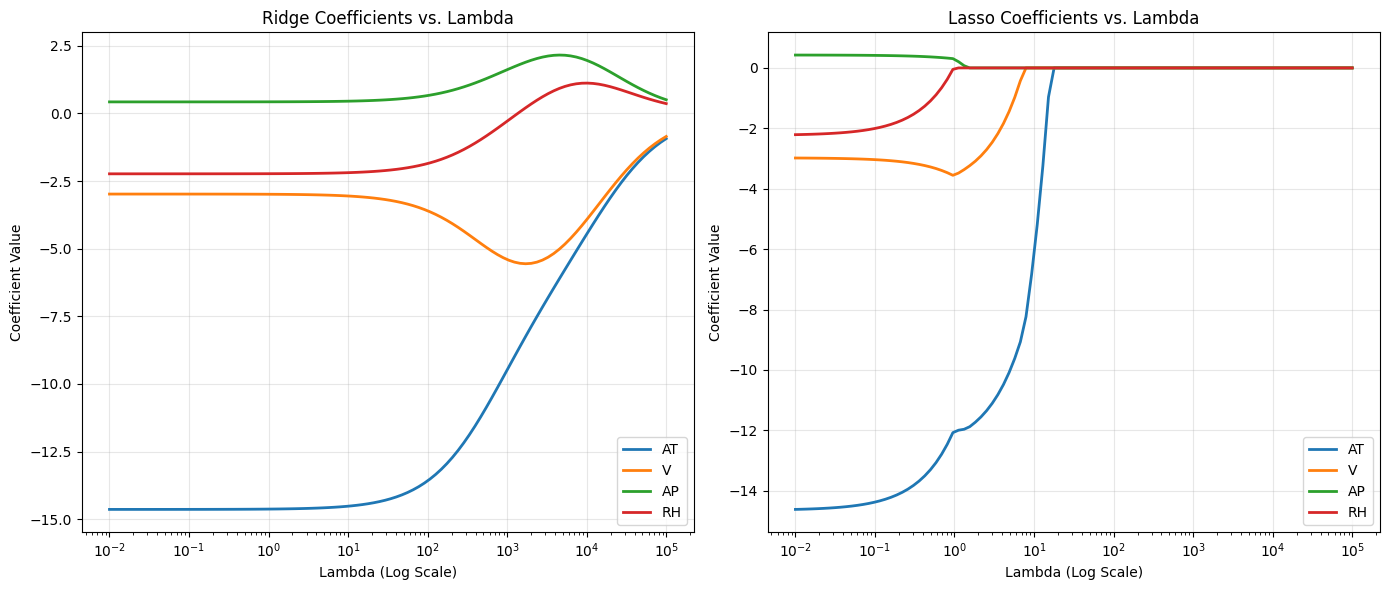

In [56]:
lambda_grid = np.logspace(-2, 5, 100)
scaler = StandardScaler()
X_train_cl_scaled = scaler.fit_transform(X_train_cl)

feature_names = X_train_cl.columns

# 2. Initialize storage for coefficients
ridge_coefs = []
lasso_coefs = []

# 3. Loop through all lambda values
for lam in lambda_grid:
    # --- Ridge ---
    ridge = Ridge(alpha=lam, random_state=42)
    ridge.fit(X_train_cl_scaled, y_train_cl.ravel())
    ridge_coefs.append(ridge.coef_)

    # --- Lasso ---
    # Max iter increased to ensure convergence for small lambdas
    lasso = Lasso(alpha=lam, max_iter=10000, random_state=42)
    lasso.fit(X_train_cl_scaled, y_train_cl.ravel())
    lasso_coefs.append(lasso.coef_)

# 4. Convert to numpy arrays for plotting (Shape: [n_lambdas, n_features])
ridge_coefs = np.array(ridge_coefs)
lasso_coefs = np.array(lasso_coefs)

# 5. Plotting
plt.figure(figsize=(14, 6))

# --- Plot 1: Ridge Regression Path ---
plt.subplot(1, 2, 1)
for i, name in enumerate(feature_names):
    plt.plot(lambda_grid, ridge_coefs[:, i], label=name, linewidth=2)
plt.xscale('log')
plt.xlabel('Lambda (Log Scale)')
plt.ylabel('Coefficient Value')
plt.title('Ridge Coefficients vs. Lambda')
plt.legend()
plt.grid(True, alpha=0.3)

# --- Plot 2: Lasso Regression Path ---
plt.subplot(1, 2, 2)
for i, name in enumerate(feature_names):
    plt.plot(lambda_grid, lasso_coefs[:, i], label=name, linewidth=2)
plt.xscale('log')
plt.xlabel('Lambda (Log Scale)')
plt.ylabel('Coefficient Value')
plt.title('Lasso Coefficients vs. Lambda')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Discussion (Required)

**1. What happens to coefficients as $\lambda$ increases in Ridge vs Lasso?**
* **Ridge:** As $\lambda$ increases, the coefficients shrink smoothly towards zero. They asymptotically approach zero, meaning all features remain in the model even at very high penalty levels.
* **Lasso:** As $\lambda$ increases, the coefficients also shrink, but they **drop to exactly zero** at specific thresholds. This creates a "sparse" model where certain features are completely removed as the penalty strength grows.

**2. Which regression is better under multicollinearity in IVs, and why?**
* **Ridge Regression** is generally better for handling multicollinearity.
* **Why:** When features are highly correlated, Lasso tends to arbitrarily select one feature and reduce the coefficients of the others to zero, which can be unstable. Ridge shrinks the coefficients of correlated features together (sharing the weight among them) rather than discarding them. This reduces the variance of the estimates while retaining the information from all correlated predictors.

**3. Which regression is better for feature selection, and why?**
* **Lasso Regression** is better for feature selection.
* **Why:** Lasso forces coefficients to become exactly zero. This automatically eliminates less important or redundant features from the model, effectively performing feature selection and resulting in a simpler, more interpretable model with fewer variables.